# Fine-Tuning a Pretrained Backbone

This notebook fine-tunes a pretrained **ResNet18** to classify cats vs. dogs. The choice
to fine-tune rather than train from scratch is the central decision of the project, so
it is worth stating the reasoning plainly.

A network trained from scratch on 17,000 photographs has to learn everything: edge
detectors, texture filters, shape composition, and finally the cat/dog distinction.
ResNet18's ImageNet weights already encode the first three, because "distinguish 1,000
object categories" requires exactly those features. Cats and dogs are themselves
ImageNet classes, so the pretrained features are close to ideal: the model mostly needs
to learn a new decision boundary over features it already computes well. The converse
marks the limit of the approach: for small, simple, low-resolution images that look
nothing like natural photographs, handwritten digits being the stock example, pretrained
features buy much less, and a compact network trained from scratch is competitive.

We will train in two phases:

1. **Frozen backbone.** Train only the new classification head. Fast, and it cannot damage the pretrained features.
2. **Partial unfreeze.** Release the last residual block and continue at a lower learning rate, letting the most task-specific features adapt.

The reason for the ordering is gradient magnitude, discussed before phase 2.

## Imports

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch.utils.data import DataLoader

from catsdogs.dataset import CatsDogsDataset, build_transforms
from catsdogs.model import build_model, unfreeze_last_blocks
from catsdogs.train import fit

PROCESSED_DIR = Path("../data/processed")
CHECKPOINT_PATH = Path("../outputs/checkpoints/best.pt")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"training on: {device}")

training on: cuda


## Data loaders

Both loaders read the split CSVs written by notebook 01, so this notebook cannot
accidentally train on validation images. The third split, the test set, is not
loaded here at all; it stays sealed until notebook 03.

The two datasets differ only in their transform, and that difference is deliberate.
Training gets `RandomResizedCrop` + horizontal flip + small rotation + color jitter;
validation gets a deterministic resize and nothing else. Augmenting the validation set
would make the metric noisy and optimistic-looking for the wrong reason.

A horizontal flip is safe for photographs of animals, since a mirrored cat is still a
cat. Note that this is *not* generally true: the same augmentation applied to MNIST
would turn some digits into nonsense, which is a good illustration of why augmentation
choices have to follow from the data rather than being copied between projects.

In [3]:
train_df = pd.read_csv(PROCESSED_DIR / "train_split.csv")
val_df = pd.read_csv(PROCESSED_DIR / "val_split.csv")

train_dataset = CatsDogsDataset(
    [Path(p) for p in train_df["path"]],
    list(train_df["label"]),
    build_transforms(train=True),
)
val_dataset = CatsDogsDataset(
    [Path(p) for p in val_df["path"]],
    list(val_df["label"]),
    build_transforms(train=False),
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

print(f"{len(train_dataset)} train / {len(val_dataset)} val images")

17471 train / 3744 val images


## Phase 1: train the classification head

`build_model` (`src/catsdogs/model.py`) loads pretrained ResNet18, freezes every
parameter, then replaces the final fully-connected layer with a fresh 2-class one.
Because the replacement happens *after* freezing, the new head is the only trainable
part.

That new head starts randomly initialized, so its early gradients are large. If the
backbone were unfrozen now, those large gradients would propagate back through it and
degrade the pretrained features we specifically want to keep, a failure mode sometimes
called catastrophic forgetting. Training the head alone first lets it reach a sensible
region before anything upstream is allowed to move.

`fit` optimizes only parameters with `requires_grad=True`, so freezing is genuinely
respected by the optimizer rather than just by convention, and it saves the best-
validation-loss checkpoint as it goes.

In [4]:
model = build_model(num_classes=2, pretrained=True)

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f"trainable: {n_trainable:,} / {n_total:,} parameters ({n_trainable / n_total:.2%})")

history_phase1 = fit(
    model,
    train_loader,
    val_loader,
    device,
    epochs=5,
    lr=1e-3,
    checkpoint_path=CHECKPOINT_PATH,
)
pd.DataFrame(history_phase1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/ian/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


trainable: 1,026 / 11,177,538 parameters (0.01%)


/home/ian/miniconda3/envs/ml/lib/python3.14/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/home/ian/miniconda3/envs/ml/lib/python3.14/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/home/ian/miniconda3/envs/ml/lib/python3.14/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/home/ian/miniconda3/envs/ml/lib/python3.14/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/home/ian/miniconda3/envs/ml/lib/python3.14/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


,epoch,train_loss,val_loss,val_accuracy
0,1,0.142224,0.067742,0.975694
1,2,0.098459,0.058745,0.977030
2,3,0.093817,0.058696,0.976496
3,4,0.092686,0.066750,0.974893
4,5,0.084264,0.053344,0.979434


Only a few thousand of ResNet18's ~11 million parameters are training here, which is why
this phase is quick even on CPU. Validation accuracy should already be high, which is
strong evidence that the pretrained features are close to sufficient and that little
genuine learning is required.

## Phase 2: unfreeze the last residual block

We reload the best phase-1 checkpoint (not necessarily the final epoch's weights), then
unfreeze `layer4` and continue at a **10x lower learning rate**.

`layer4` is the deepest block, holding the most abstract and task-specific features; the
earlier blocks hold generic edge and texture detectors that transfer as-is and are
better left alone. The reduced learning rate is the important detail: the head is now
trained rather than random, so gradients are small, and we want to nudge these features
rather than overwrite them.

Whether this phase helps is an empirical question, not a guarantee. Compare the
validation loss against phase 1. On a task this close to ImageNet the gain is often
marginal, and saying so is more honest than presenting the second phase as automatically
worthwhile.

In [5]:
model.load_state_dict(torch.load(CHECKPOINT_PATH))
unfreeze_last_blocks(model, num_blocks=1)

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"trainable after unfreeze: {n_trainable:,} / {n_total:,} ({n_trainable / n_total:.2%})")

history_phase2 = fit(
    model,
    train_loader,
    val_loader,
    device,
    epochs=5,
    lr=1e-4,
    checkpoint_path=CHECKPOINT_PATH,
)
pd.DataFrame(history_phase2)

trainable after unfreeze: 8,394,754 / 11,177,538 (75.10%)


/home/ian/miniconda3/envs/ml/lib/python3.14/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/home/ian/miniconda3/envs/ml/lib/python3.14/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/home/ian/miniconda3/envs/ml/lib/python3.14/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/home/ian/miniconda3/envs/ml/lib/python3.14/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/home/ian/miniconda3/envs/ml/lib/python3.14/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


,epoch,train_loss,val_loss,val_accuracy
0,1,0.086490,0.039409,0.987447
1,2,0.047039,0.037328,0.986378
2,3,0.035571,0.041614,0.985577
3,4,0.029545,0.038359,0.988248
4,5,0.025982,0.048403,0.981838


## Training curves

Both phases plotted on one axis, with a marker where `layer4` was unfrozen. Three things
are worth reading off this figure:

* **The step at the unfreeze line.** A drop in validation loss means phase 2 earned its keep; a flat or rising curve means the model had already extracted what the pretrained features offer.
* **Train/validation gap.** Divergence indicates overfitting. With most of the backbone frozen there are few free parameters to overfit *with*, so a large gap here would be surprising and worth investigating.
* **Where the best checkpoint landed.** `fit` tracks validation loss, so the saved weights need not come from the last epoch.

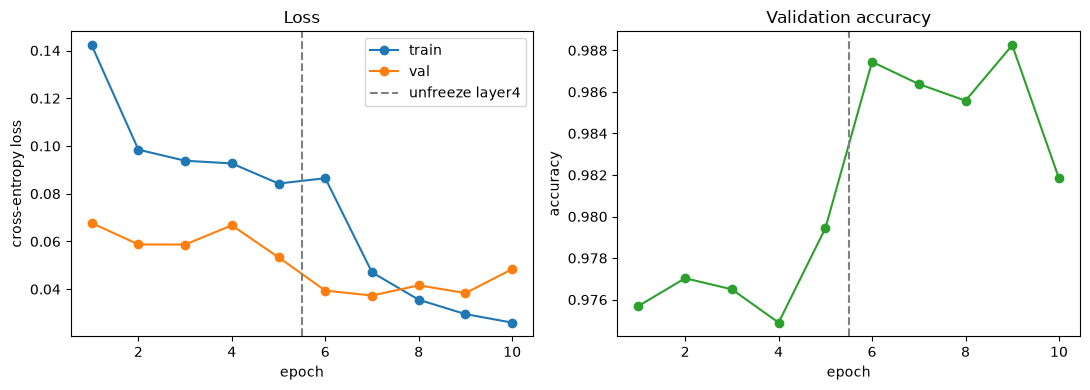

best epoch: 7 (val_loss=0.0373, val_accuracy=0.9864)


In [6]:
history = pd.DataFrame(history_phase1 + history_phase2)
history["epoch"] = range(1, len(history) + 1)
unfreeze_at = len(history_phase1) + 0.5

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["epoch"], history["train_loss"], marker="o", label="train")
axes[0].plot(history["epoch"], history["val_loss"], marker="o", label="val")
axes[0].axvline(unfreeze_at, color="gray", linestyle="--", label="unfreeze layer4")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("cross-entropy loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["epoch"], history["val_accuracy"], marker="o", color="tab:green")
axes[1].axvline(unfreeze_at, color="gray", linestyle="--")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_title("Validation accuracy")

plt.tight_layout()
plt.savefig("../outputs/figures/training_curves.png", dpi=150)
plt.show()

best = history.loc[history["val_loss"].idxmin()]
print(f"best epoch: {int(best['epoch'])} "
      f"(val_loss={best['val_loss']:.4f}, val_accuracy={best['val_accuracy']:.4f})")

## Closing notes

Ten epochs over two phases, with the large majority of the network frozen throughout,
is enough to reach the validation accuracy reported above. That result says as much
about the problem as about the method: cats and dogs are well represented in
ImageNet, so this is close to the easiest possible transfer-learning scenario.

Note that the validation figure is not the number this project reports as its
result. The checkpoint above was chosen by taking the best validation loss across
every epoch, which makes that score a maximum over ten attempts rather than a clean
measurement. Notebook 03 re-measures on the held-out test split, which nothing in
this notebook has been allowed to see.

Which is precisely why the accuracy number is not where this project stops. A high score
on a balanced binary task leaves the interesting questions unanswered. *Which* images
does it still get wrong, and is it looking at the animal at all, or at some background
cue that happens to correlate with the label? Notebook 03 takes up both, with per-class
metrics, a confusion matrix, Grad-CAM attention maps, and an error analysis of the most
confidently wrong predictions.